# Customer Segmentation Analysis using K-Means Clustering

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

## 2. Load the Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Check Dataset Shape

In [4]:
df.shape

(200, 5)

## 4. Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## 5. Check Missing Values

In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 6. Descriptive Statistics

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 7. Gender Distribution

In [9]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

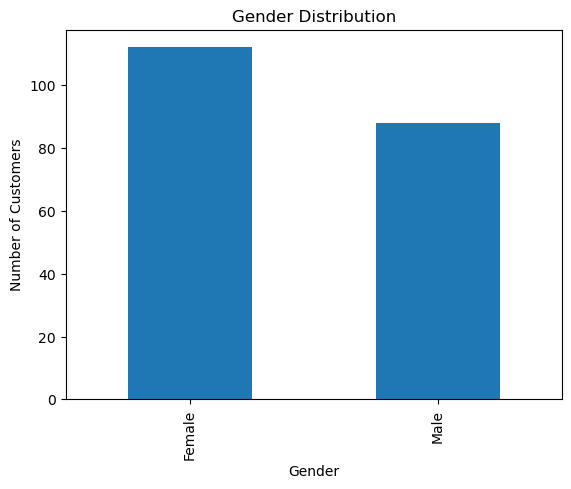

In [10]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

Observation:
The dataset contains 112 female customers and 88 male customers. Female customers are slightly more than male customers.

## 8. Age Distribution

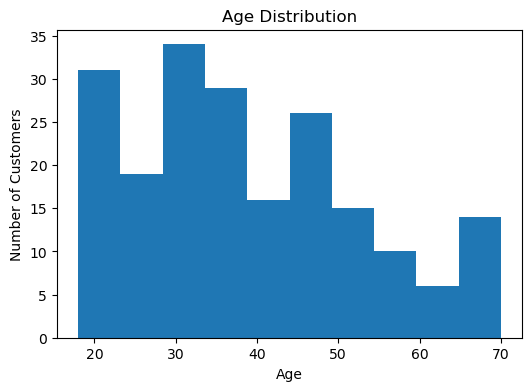

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

Observation:
Most customers are between 20 and 40 years of age. The number of customers decreases as age increases, with fewer customers above 60 years.

## 9. Annual Income Distribution

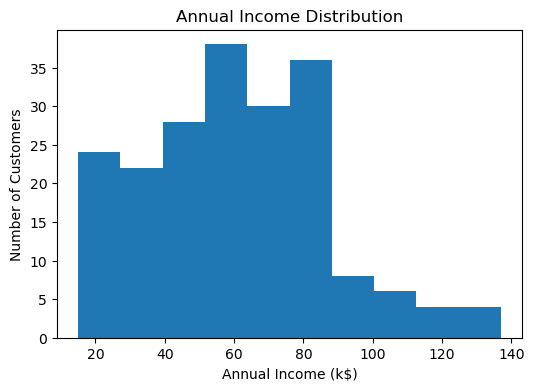

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df["Annual Income (k$)"], bins=10)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

Observation:
Customers have different levels of annual income, ranging from low to high. Most customers fall into the middle income range.

## 10. Spending Score Distribution

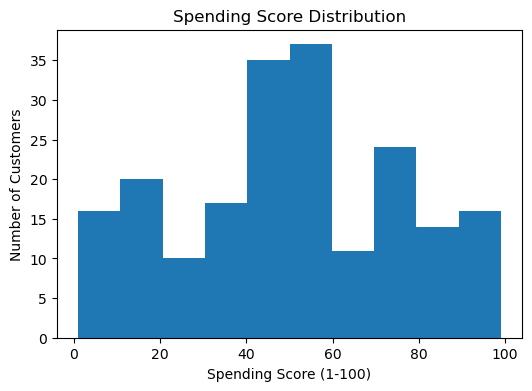

In [16]:
plt.figure(figsize=(6,4))
plt.hist(df["Spending Score (1-100)"], bins=10)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")
plt.show()

Observation:
The spending scores are distributed across different ranges, showing that the dataset contains customers with low, medium, and high spending behavior.

## 11. Annual Income vs Spending Score

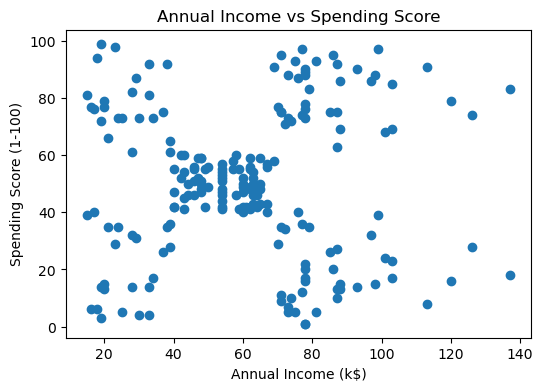

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"])
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

Observation:
The scatter plot shows the relationship between Annual Income and Spending Score. Customers appear to form different groups, making the dataset suitable for K-Means clustering.

# Machine Learning

## 12. Finding the Optimal Number of Clusters (Elbow Method)

In [28]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [29]:
wcss = []

In [30]:
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

C:\Users\supre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\supre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\supre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\supre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

## 13. Elbow Method

In [31]:
len(wcss)

10

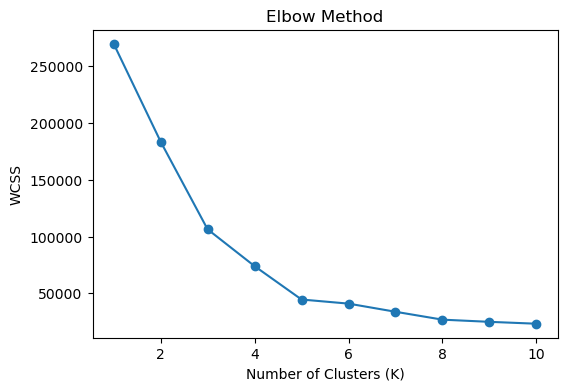

In [32]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

## 14. Apply K-Means Clustering

In [33]:
kmeans = KMeans(n_clusters=5, random_state=42)

In [34]:
df["Cluster"] = kmeans.fit_predict(X)
df["Cluster"]

C:\Users\supre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0      4
1      2
2      4
3      2
4      4
      ..
195    1
196    3
197    1
198    3
199    1
Name: Cluster, Length: 200, dtype: int32

In [35]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## 15. Visualizing Customer Segments

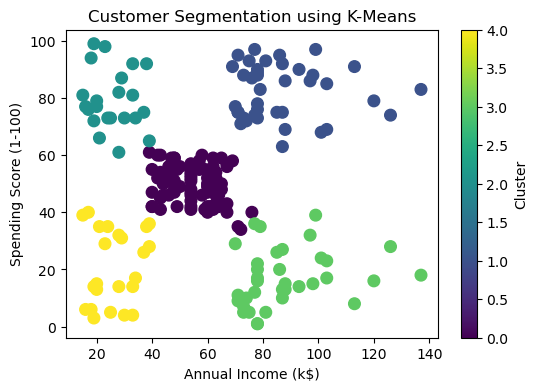

In [42]:
plt.figure(figsize=(6,4))
scatter = plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=70
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(scatter, label="Cluster")
plt.show()

## 16. Cluster Summary

In [43]:
df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


### Observation

The customers are divided into five clusters based on Annual Income and Spending Score.

- Some clusters contain customers with high income and high spending.
- Some clusters represent high income but low spending customers.
- Other clusters include low income with high or low spending.
- These customer groups can help businesses design personalized marketing strategies.

## 17. Save the Clustered Dataset

In [44]:
df.to_csv("Customer_Segments.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!


## 18. Conclusion

### Conclusion

Customer segmentation was successfully performed using the K-Means Clustering algorithm.

The Elbow Method was used to determine the optimal number of clusters (K = 5). Customers were grouped based on their Annual Income and Spending Score, allowing meaningful customer segments to be identified.

This analysis can help businesses improve marketing campaigns, customer targeting, and decision-making.